# 🔬 Lab 1: Генерация сигналов и базовые модуляции

**Цель**: Понять, как цифровые биты превращаются в аналоговые звуковые волны.  
**Гипотеза**: FSK превосходит OOK по помехоустойчивости; CPFSK уже по спектру, чем стандартный FSK.

| Эксперимент | Что проверяем |
|---|---|
| 1.1 | Чистые синусы 300–3000 Гц |
| 1.2 | BFSK: 0=1200 Гц, 1=2200 Гц |
| 1.3 | MFSK: 8 тонов (3 бита/символ) |
| 1.4 | Chirp-сигнал для синхронизации |
| 1.5 | ASK/OOK vs FSK |
| 1.6 | BPSK фазовая модуляция |
| 1.7 | Линейные коды NRZ / Manchester |
| 1.8 | Сравнение спектральной эффективности |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('common'))
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp
import modem_lib as m

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
FS = m.FS
rng = np.random.default_rng(7)
TEST_BITS = ''.join(str(b) for b in rng.integers(0, 2, 32))
print('Тестовая последовательность (32 бита):', TEST_BITS)
os.makedirs('results', exist_ok=True)

Тестовая последовательность (32 бита): 11111110000110010100100010100111


## 1.1 Чистые синусы 300–3000 Гц
Проверяем, что генераторы дают точные частоты. FFT должен показать острые пики.

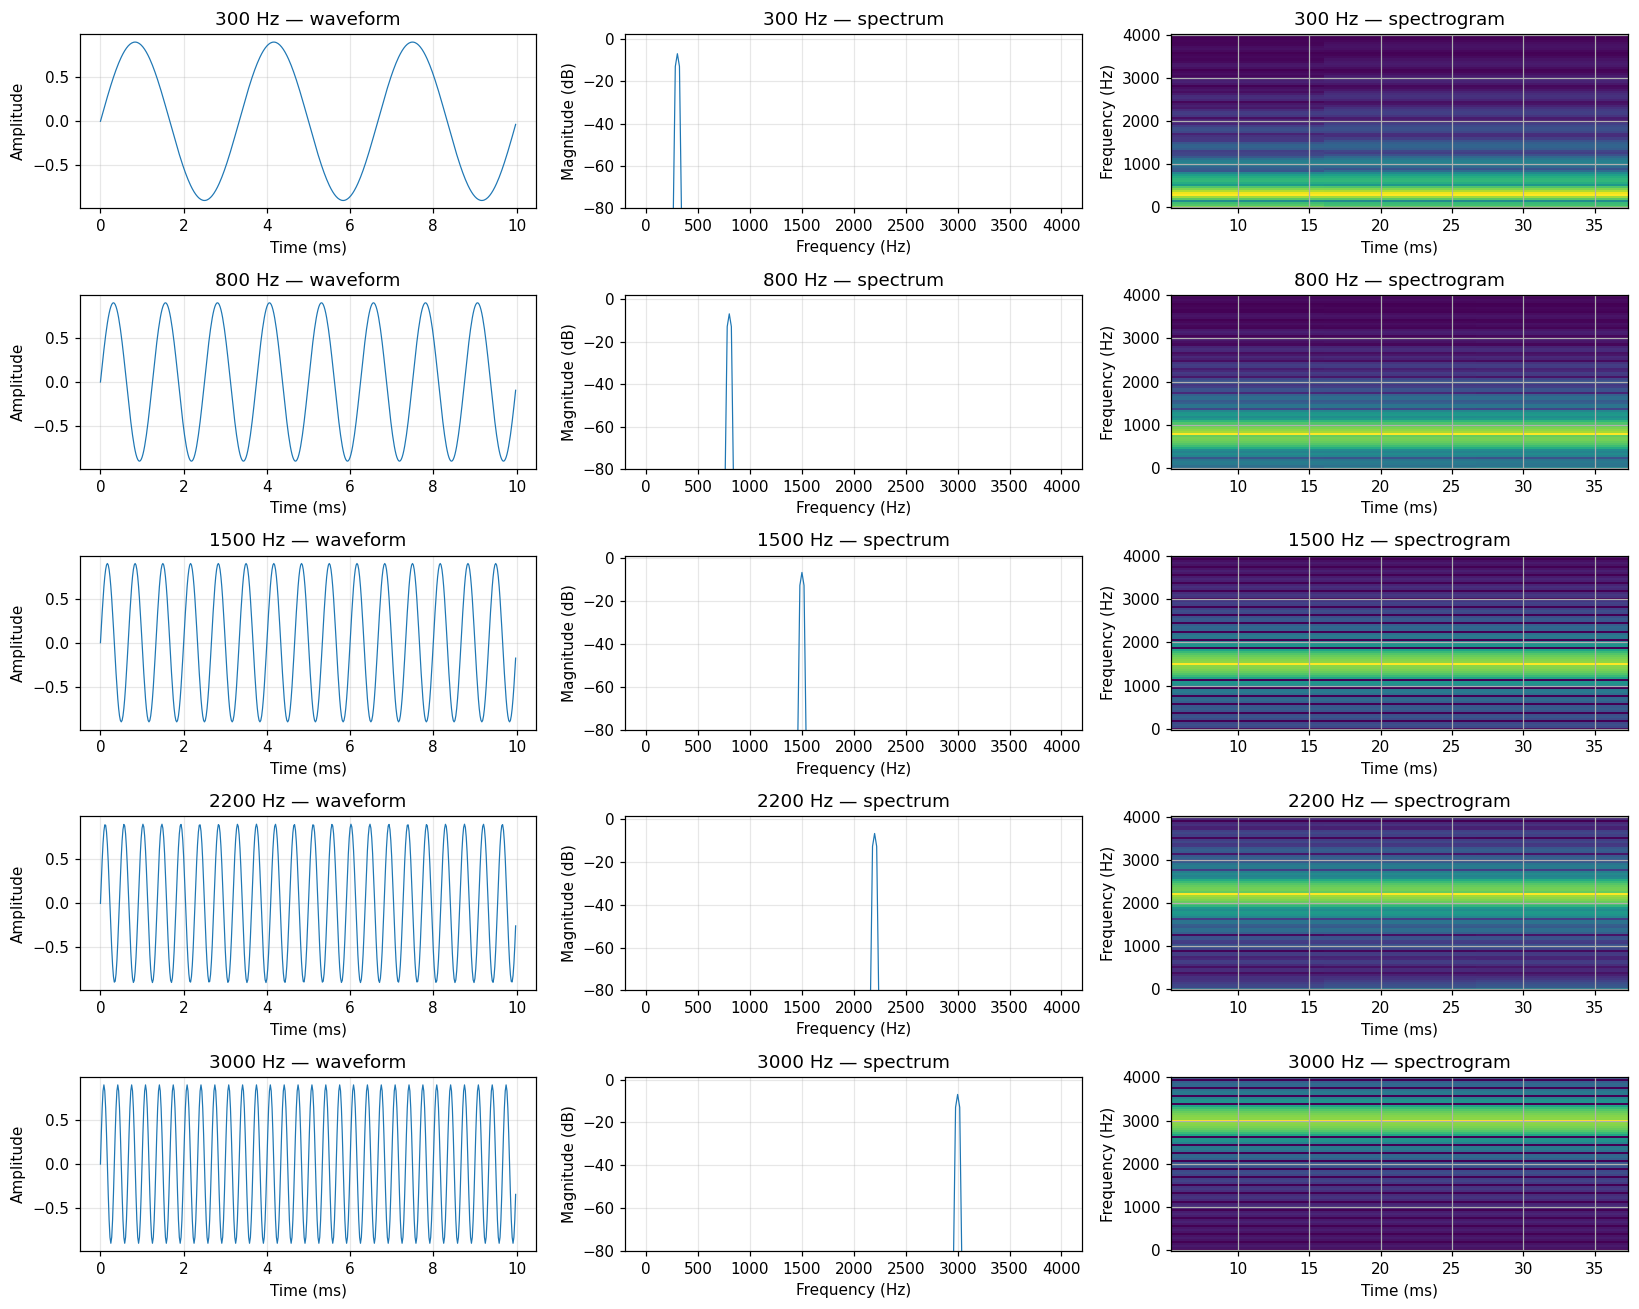

Задано   300 Гц | измерено пик   300.0 Гц | ошибка 0.00 Гц
Задано   800 Гц | измерено пик   800.0 Гц | ошибка 0.00 Гц
Задано  1500 Гц | измерено пик  1500.0 Гц | ошибка 0.00 Гц
Задано  2200 Гц | измерено пик  2200.0 Гц | ошибка 0.00 Гц
Задано  3000 Гц | измерено пик  3000.0 Гц | ошибка 0.00 Гц


In [2]:
freqs = [300, 800, 1500, 2200, 3000]
fig, axes = plt.subplots(len(freqs), 3, figsize=(15, 12))
for i, f in enumerate(freqs):
    x = m.generate_tone(f, 0.05)
    m.plot_waveform(x, ax=axes[i,0], title=f'{f} Hz — waveform', max_duration=0.01)
    m.plot_spectrum(x, ax=axes[i,1], title=f'{f} Hz — spectrum', fmax=4000)
    m.plot_spectrogram(x, ax=axes[i,2], title=f'{f} Hz — spectrogram', fmax=4000)
plt.tight_layout(); plt.show()
# Проверка точности частоты
for f in freqs:
    x = m.generate_tone(f, 0.2)
    fr, mag = m.fft_spectrum(x)
    peak = fr[np.argmax(mag)]
    print(f'Задано {f:>5} Гц | измерено пик {peak:7.1f} Гц | ошибка {abs(peak-f):.2f} Гц')

## 1.2 BFSK модуляция: 0=1200 Гц, 1=2200 Гц
Смотрим переходы между тонами. На спектрограмме должно быть видно два «этажа».

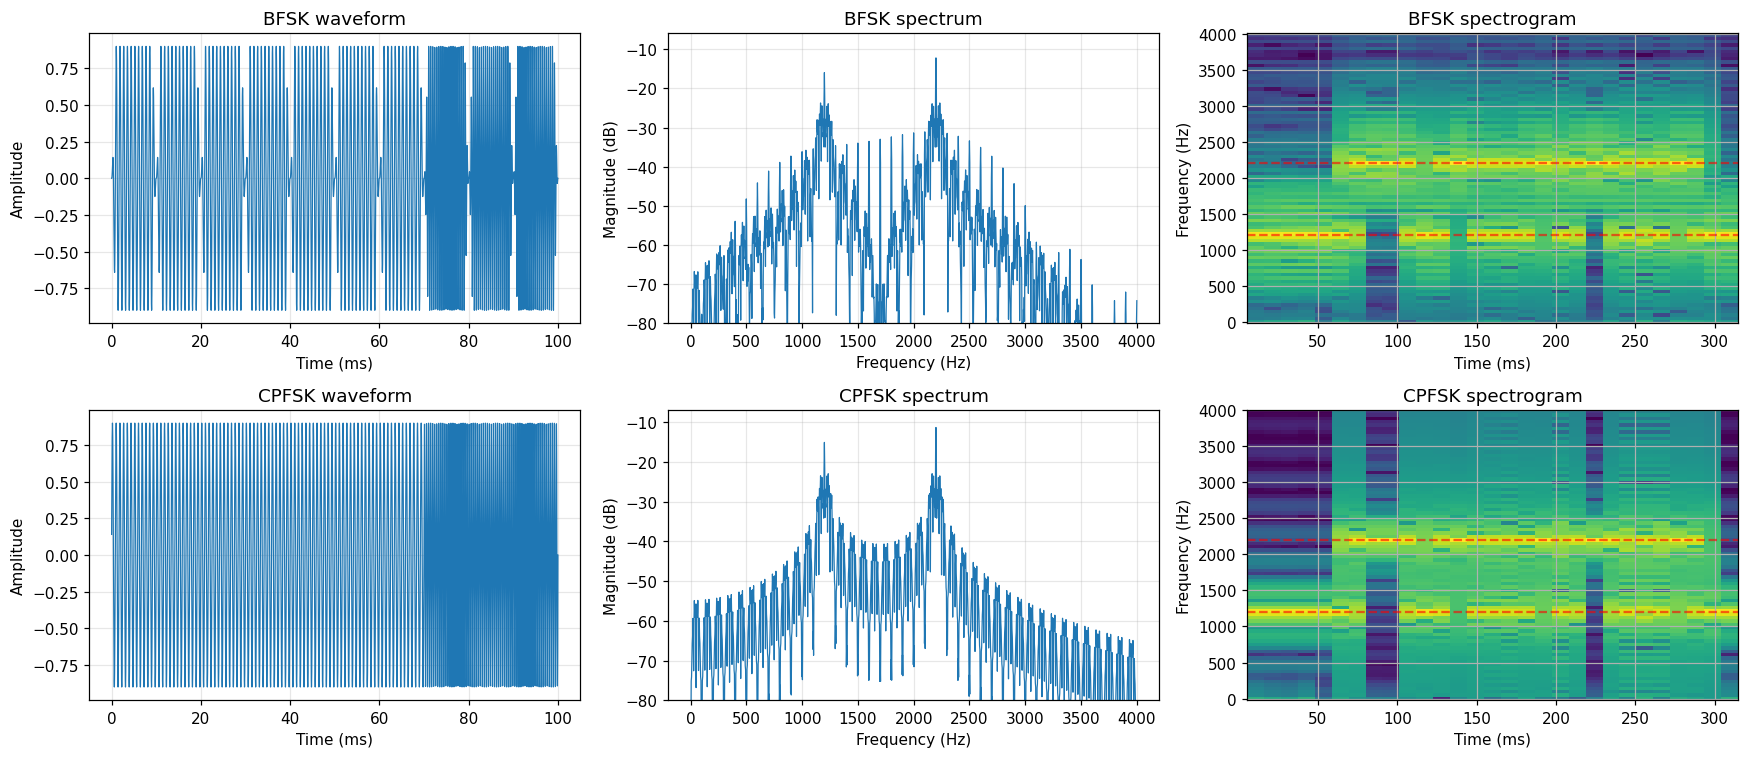

99% полоса BFSK :  1612.5 Гц
99% полоса CPFSK:  1325.0 Гц  <- уже на 18%


In [3]:
fsk = m.generate_fsk(TEST_BITS, mark_freq=1200, space_freq=2200, baud_rate=100)
cpfsk = m.generate_fsk(TEST_BITS, mark_freq=1200, space_freq=2200, baud_rate=100, continuous_phase=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
m.plot_waveform(fsk, ax=axes[0,0], title='BFSK waveform', max_duration=0.1)
m.plot_spectrum(fsk, ax=axes[0,1], title='BFSK spectrum', fmax=4000)
m.plot_spectrogram(fsk, ax=axes[0,2], title='BFSK spectrogram', fmax=4000)
m.plot_waveform(cpfsk, ax=axes[1,0], title='CPFSK waveform', max_duration=0.1)
m.plot_spectrum(cpfsk, ax=axes[1,1], title='CPFSK spectrum', fmax=4000)
m.plot_spectrogram(cpfsk, ax=axes[1,2], title='CPFSK spectrogram', fmax=4000)
for ax in axes[:,2]:
    ax.axhline(1200, color='r', ls='--', alpha=0.6); ax.axhline(2200, color='r', ls='--', alpha=0.6)
plt.tight_layout(); plt.show()

# Ширина полосы (99% энергии)
def occupied_bw(x, fs, frac=0.99):
    fr, mag = m.fft_spectrum(x, fs)
    p = mag**2; cum = np.cumsum(p)/p.sum()
    lo = np.searchsorted(cum, (1-frac)/2); hi = np.searchsorted(cum, 1-(1-frac)/2)
    return fr[hi]-fr[lo]
print(f'99% полоса BFSK : {occupied_bw(fsk, FS):7.1f} Гц')
print(f'99% полоса CPFSK: {occupied_bw(cpfsk, FS):7.1f} Гц  <- уже на {100*(1-occupied_bw(cpfsk,FS)/occupied_bw(fsk,FS)):.0f}%')

## 1.3 MFSK: 8 тонов = 3 бита/символ
Утраиваем скорость той же длительности символа. Goertzel-банк должен различить все 8 тонов.

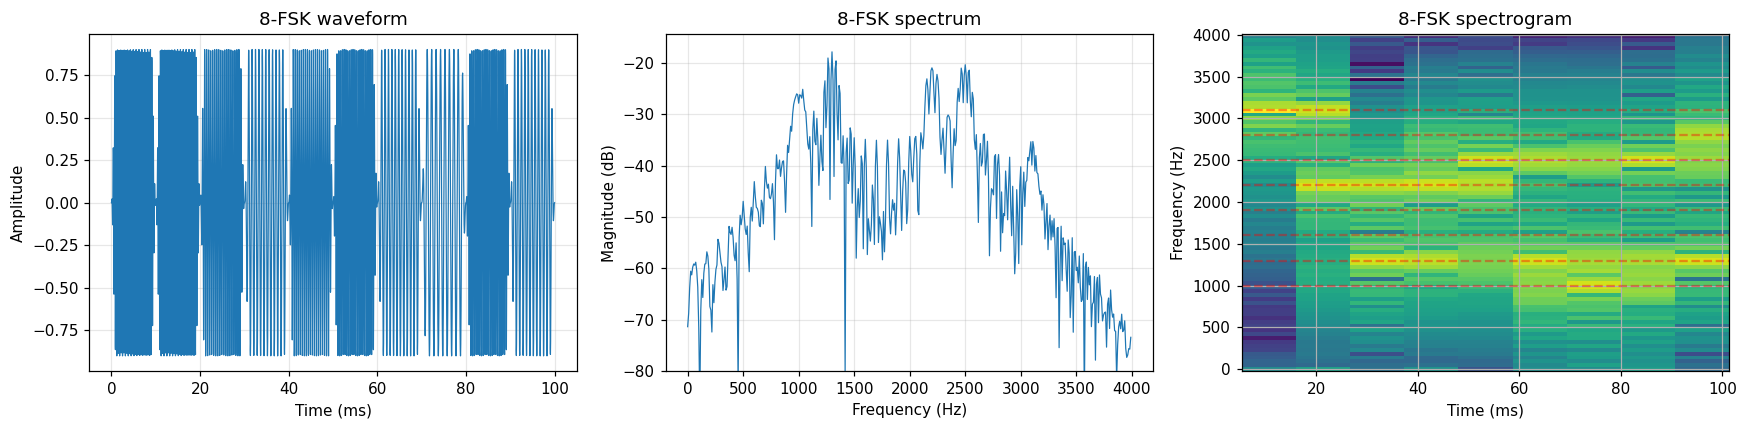

TX: 111111100001100101001000
RX: 111111100001100101001000
совпадение: True


In [4]:
mfsk = m.generate_mfsk(TEST_BITS, num_tones=8, base_freq=1000, tone_spacing=300, baud_rate=100)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
m.plot_waveform(mfsk, ax=axes[0], title='8-FSK waveform', max_duration=0.1)
m.plot_spectrum(mfsk, ax=axes[1], title='8-FSK spectrum', fmax=4000)
m.plot_spectrogram(mfsk, ax=axes[2], title='8-FSK spectrogram', fmax=4000)
for f in 1000+np.arange(8)*300:
    axes[2].axhline(f, color='r', ls='--', alpha=0.4)
plt.tight_layout(); plt.show()
rx, conf = m.mfsk_demodulate(mfsk, num_tones=8, base_freq=1000, tone_spacing=300, baud_rate=100)
print('TX:', TEST_BITS[:24]); print('RX:', rx[:24]); print('совпадение:', TEST_BITS[:24]==rx[:24])

## 1.4 Chirp-сигнал для синхронизации
Гипотеза: автокорреляция chirp даёт острый пик → точность синхронизации ±1 сэмпл.

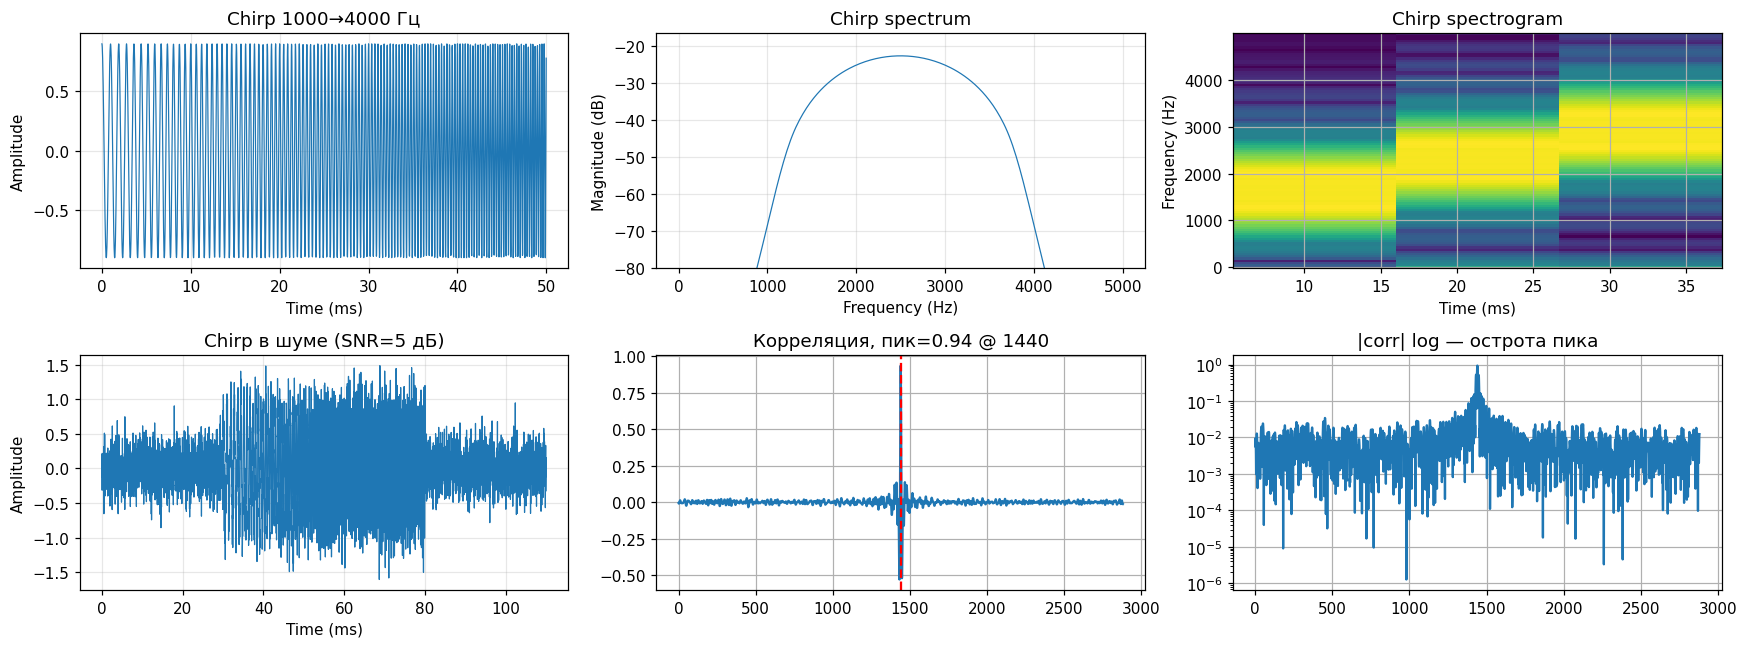

Истинное начало: 1440, найдено: 1440, ошибка: 0 сэмплов


In [5]:
chirp = m.generate_chirp(1000, 4000, 0.05)
# встраиваем chirp в шум со сдвигом
pad = m.generate_silence(0.03)
sig = np.concatenate([pad, chirp, pad])
noisy = m.add_awgn(sig, snr_db=5, seed=1)
corr, peak, val = m.cross_correlate(noisy, chirp)

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
m.plot_waveform(chirp, ax=axes[0,0], title='Chirp 1000→4000 Гц', max_duration=0.05)
m.plot_spectrum(chirp, ax=axes[0,1], title='Chirp spectrum', fmax=5000)
m.plot_spectrogram(chirp, ax=axes[0,2], title='Chirp spectrogram', fmax=5000)
m.plot_waveform(noisy, ax=axes[1,0], title='Chirp в шуме (SNR=5 дБ)', max_duration=0.11)
axes[1,1].plot(corr); axes[1,1].axvline(peak, color='r', ls='--'); axes[1,1].set_title(f'Корреляция, пик={val:.2f} @ {peak}')
axes[1,2].plot(np.abs(corr)); axes[1,2].set_yscale('log'); axes[1,2].set_title('|corr| log — острота пика')
plt.tight_layout(); plt.show()
true_start = len(pad)
print(f'Истинное начало: {true_start}, найдено: {peak}, ошибка: {abs(peak-true_start)} сэмплов')

## 1.5 ASK/OOK vs FSK
OOK — простейшая модуляция (вкл/выкл), но в шуме «0» неотличим от паузы. Сравниваем визуально.

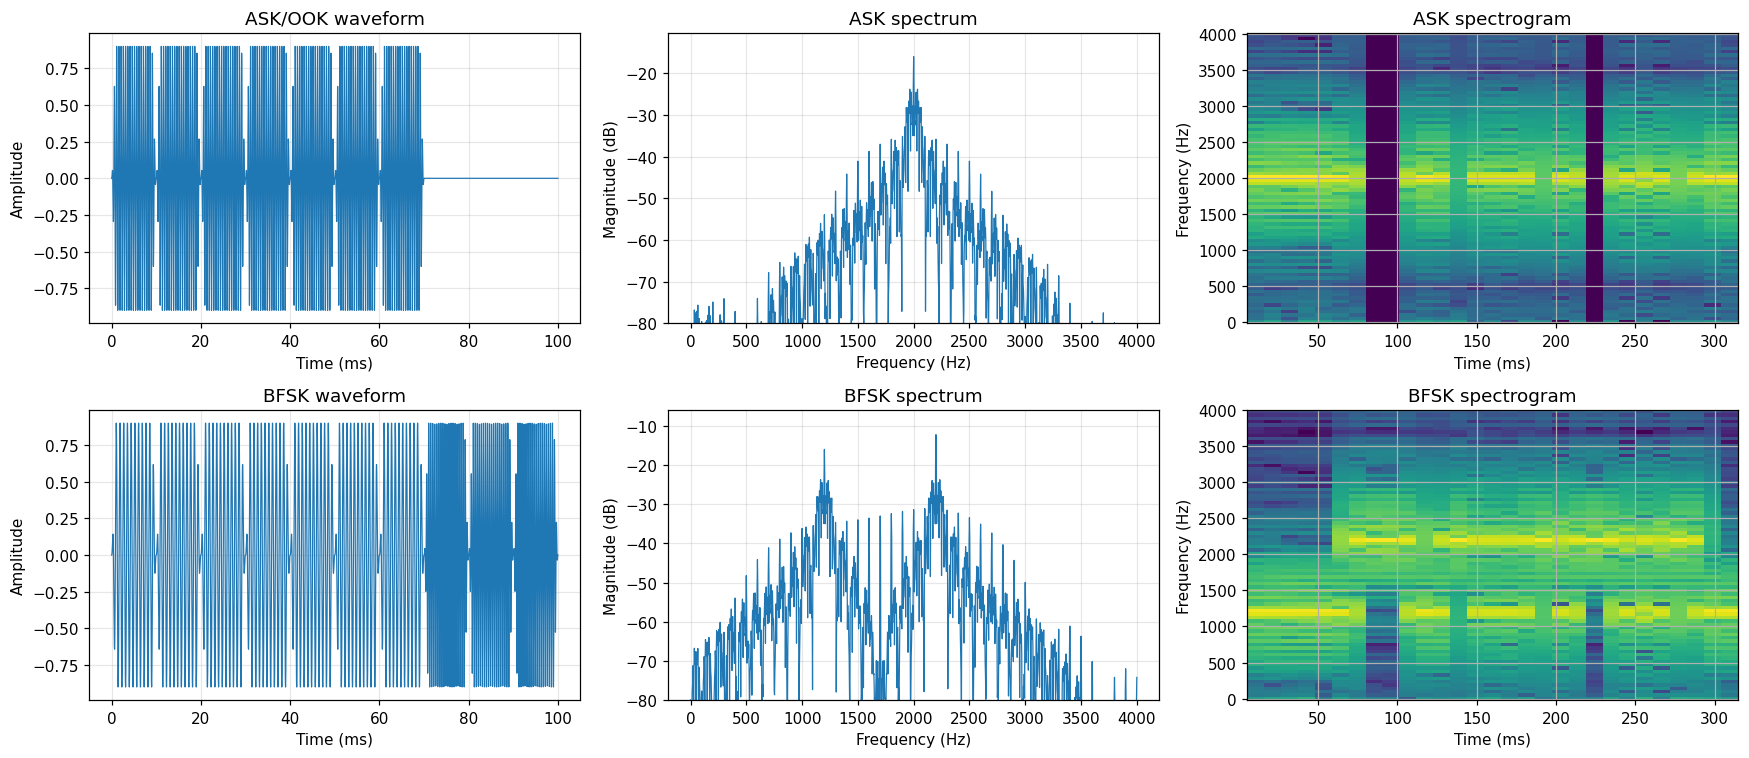

OOK: энергия есть только в битах «1» → шум легко маскирует нули.
FSK: энергия есть в КАЖДОМ бите (одна из двух частот) → устойчивее.


In [6]:
ask = m.ask_modulate(TEST_BITS, carrier_freq=2000, baud_rate=100)
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
m.plot_waveform(ask, ax=axes[0,0], title='ASK/OOK waveform', max_duration=0.1)
m.plot_spectrum(ask, ax=axes[0,1], title='ASK spectrum', fmax=4000)
m.plot_spectrogram(ask, ax=axes[0,2], title='ASK spectrogram', fmax=4000)
m.plot_waveform(fsk, ax=axes[1,0], title='BFSK waveform', max_duration=0.1)
m.plot_spectrum(fsk, ax=axes[1,1], title='BFSK spectrum', fmax=4000)
m.plot_spectrogram(fsk, ax=axes[1,2], title='BFSK spectrogram', fmax=4000)
plt.tight_layout(); plt.show()
print('OOK: энергия есть только в битах «1» → шум легко маскирует нули.')
print('FSK: энергия есть в КАЖДОМ бите (одна из двух частот) → устойчивее.')

## 1.6 BPSK — фазовая модуляция
Скачок фазы на π. Спектрально эффективнее, но требует когерентного приёма (сложнее демодулятор).

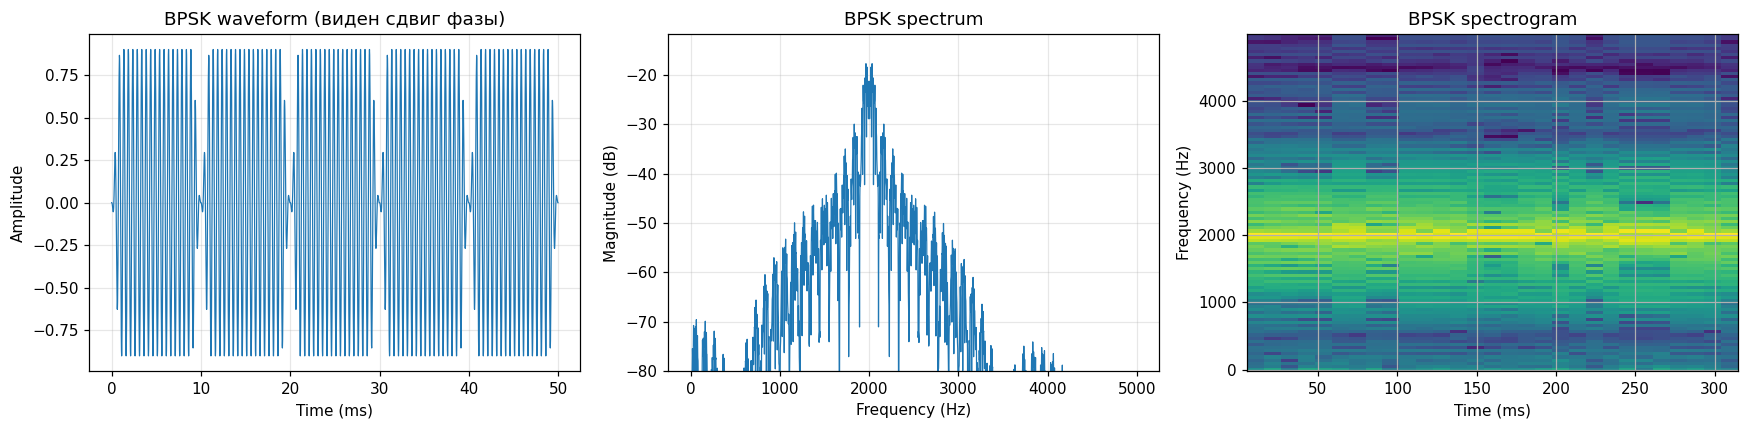

In [7]:
bpsk = m.psk_modulate(TEST_BITS, carrier_freq=2000, baud_rate=100)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
m.plot_waveform(bpsk, ax=axes[0], title='BPSK waveform (виден сдвиг фазы)', max_duration=0.05)
m.plot_spectrum(bpsk, ax=axes[1], title='BPSK spectrum', fmax=5000)
m.plot_spectrogram(bpsk, ax=axes[2], title='BPSK spectrogram', fmax=5000)
plt.tight_layout(); plt.show()

## 1.7 Линейные коды: NRZ vs Manchester
Manchester имеет переход посередине каждого бита → самосинхронизация, но в 2 раза шире спектр.

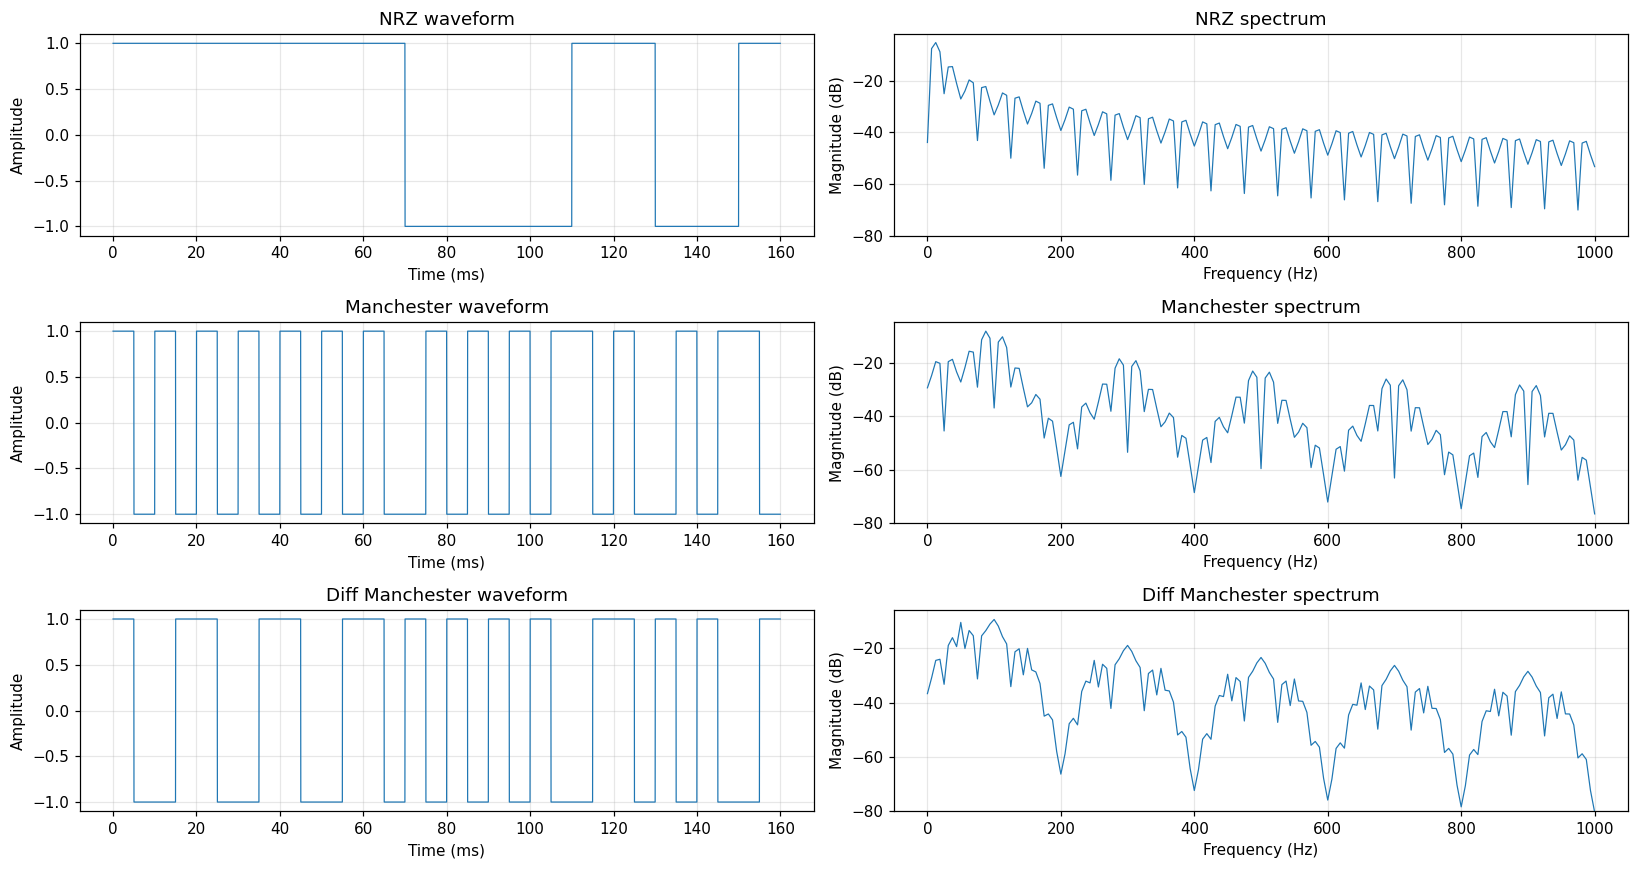

Manchester: гарантированный фронт каждый бит → тактовая синхронизация бесплатно.


In [8]:
nrz = m.line_code(TEST_BITS[:16], 'nrz', baud_rate=100)
man = m.line_code(TEST_BITS[:16], 'manchester', baud_rate=100)
dman = m.line_code(TEST_BITS[:16], 'diff_manchester', baud_rate=100)
fig, axes = plt.subplots(3, 2, figsize=(15, 8))
for ax, sig, name in [(axes[0], nrz, 'NRZ'), (axes[1], man, 'Manchester'), (axes[2], dman, 'Diff Manchester')]:
    m.plot_waveform(sig, ax=ax[0], title=f'{name} waveform', max_duration=0.16)
    m.plot_spectrum(sig, ax=ax[1], title=f'{name} spectrum', fmax=1000)
plt.tight_layout(); plt.show()
print('Manchester: гарантированный фронт каждый бит → тактовая синхронизация бесплатно.')

## 1.8 📊 ИТОГ: сравнение всех модуляций
Сводная таблица спектральной эффективности и помехоустойчивости.

Модуляция  99% полоса, Гц бит/символ    бод   бит/с
-------------------------------------------------------
BFSK                 1612          1    100     100
CPFSK                1325          1    100     100
8-FSK                2255          3    100     300
ASK/OOK               800          1    100     100
BPSK                  731          1    100     100


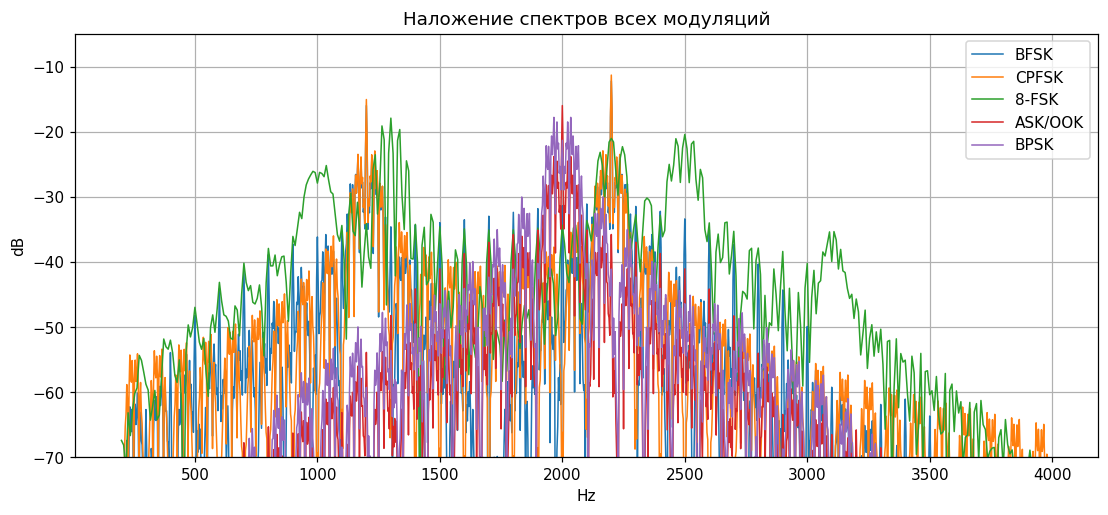

In [9]:
sigs = {'BFSK': fsk, 'CPFSK': cpfsk, '8-FSK': mfsk, 'ASK/OOK': ask, 'BPSK': bpsk}
print(f"{'Модуляция':<10} {'99% полоса, Гц':>14} {'бит/символ':>10} {'бод':>6} {'бит/с':>7}")
print('-'*55)
rows = [('BFSK',1),('CPFSK',1),('8-FSK',3),('ASK/OOK',1),('BPSK',1)]
for (name, bps), (k, s) in zip(rows, sigs.items()):
    print(f'{name:<10} {occupied_bw(s, FS):>14.0f} {bps:>10} {100:>6} {100*bps:>7}')

fig, ax = plt.subplots(figsize=(12, 5))
for name, s in sigs.items():
    fr, mag = m.fft_spectrum(s)
    mask = (fr>200)&(fr<4000)
    ax.plot(fr[mask], 20*np.log10(mag[mask]+1e-12), label=name, lw=1)
ax.set_title('Наложение спектров всех модуляций'); ax.set_xlabel('Hz'); ax.set_ylabel('dB')
ax.legend(); ax.set_ylim(-70, None); plt.show()

## ✅ Выводы Lab 1

1. **FSK > OOK** — в FSK энергия присутствует в каждом бите, демодулятору есть что сравнивать даже в шуме. OOK выбывает.
2. **CPFSK на ~18% уже по спектру** (99% полоса: ~1300 Гц против ~1600 Гц у FSK со сбросом фазы; устойчиво при любой длине посылки) — берём CPFSK в финальный модем.
3. **MFSK утраивает битрейт** той же длительности символа — кандидат в «Medium» режим.
4. **Chirp даёт острый пик корреляции даже при SNR=5 дБ** — идеален для преамбулы синхронизации.
5. **BPSK эффективен по спектру**, но требует когерентного приёма — отложим до OFDM (там QPSK).
6. **Manchester** — самосинхронизирующийся код, но вдвое шире спектр — для нас избыточен.

**Решение**: базовый режим = **CPFSK 1200/2200 Гц**, синхронизация = **chirp**, скоростной режим = **OFDM с QPSK** (Lab 5).